<a href="https://colab.research.google.com/github/Katyayini-Sharma/Celebal-Internship-2026/blob/main/week_5_Text_Generation_RNN_LSTM_GRU_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

## ✓ TASKS PERFORMED AT THE END

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

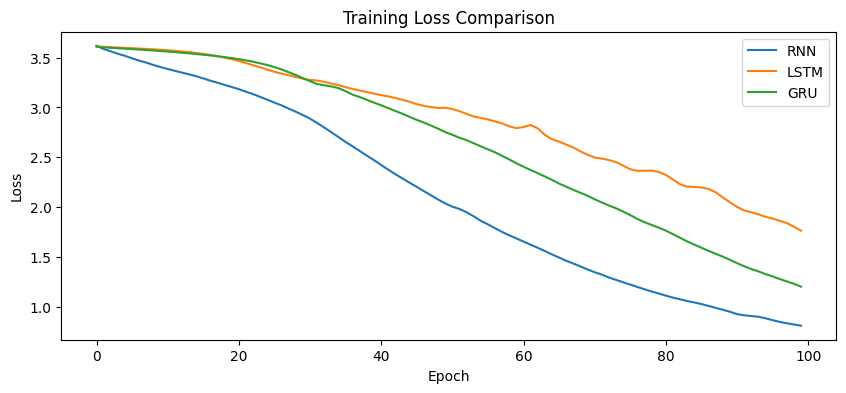

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning is transforming artificial than than
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## Task 1: Replace corpus with a custom paragraph


In [10]:
custom_corpus = '''
Artificial Intelligence (AI) has rapidly transformed from a futuristic concept into an indispensable cornerstone of modern civilization. At its core, AI refers to the ability of digital computers or computer-controlled robots to perform tasks commonly associated with intelligent beings, such as learning, reasoning, and problem-solving. Today, its footprint is visible across nearly every sector. In healthcare, machine learning algorithms analyze complex medical data to predict diseases and assist in drug discovery. In finance, AI drives algorithmic trading and detects fraudulent activities in real time. Meanwhile, generative AI tools have redefined human productivity, streamlining content creation, coding, and administrative workflows.
'''
print(custom_corpus)


Artificial Intelligence (AI) has rapidly transformed from a futuristic concept into an indispensable cornerstone of modern civilization. At its core, AI refers to the ability of digital computers or computer-controlled robots to perform tasks commonly associated with intelligent beings, such as learning, reasoning, and problem-solving. Today, its footprint is visible across nearly every sector. In healthcare, machine learning algorithms analyze complex medical data to predict diseases and assist in drug discovery. In finance, AI drives algorithmic trading and detects fraudulent activities in real time. Meanwhile, generative AI tools have redefined human productivity, streamlining content creation, coding, and administrative workflows.



## Task 2 & 4: Increase embedding dimension & Wider hidden layers


In [11]:
custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts([custom_corpus])

custom_total_words = len(custom_tokenizer.word_index) + 1
print("Vocabulary size:", custom_total_words)

custom_input_sequences = []
for line in custom_corpus.split('\n'):
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        custom_input_sequences.append(n_gram_seq)

custom_max_len = max(len(seq) for seq in custom_input_sequences)
custom_input_sequences = pad_sequences(custom_input_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_input_sequences[:, :-1]
y_custom = custom_input_sequences[:, -1]

print("X_custom shape:", X_custom.shape)
print("y_custom shape:", y_custom.shape)

EMBED_DIM = 64    # increased from 32
HIDDEN_UNITS = 128  # increased from 64
EPOCHS = 200        # increased from 100, this is Task 3

Vocabulary size: 88
X_custom shape: (100, 100)
y_custom shape: (100,)


## Task 3: Increase epochs to 200

In [12]:
custom_rnn_model = Sequential([
    Embedding(custom_total_words, EMBED_DIM, input_length=custom_max_len-1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])
custom_rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_rnn_history = custom_rnn_model.fit(X_custom, y_custom, epochs=EPOCHS, verbose=0)
print("Custom Vanilla RNN training completed")

Custom Vanilla RNN training completed


In [13]:
custom_lstm_model = Sequential([
    Embedding(custom_total_words, EMBED_DIM, input_length=custom_max_len-1),
    LSTM(HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])
custom_lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_lstm_history = custom_lstm_model.fit(X_custom, y_custom, epochs=EPOCHS, verbose=0)
print("Custom LSTM training completed")

Custom LSTM training completed


In [14]:
custom_gru_model = Sequential([
    Embedding(custom_total_words, EMBED_DIM, input_length=custom_max_len-1),
    GRU(HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])
custom_gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_gru_history = custom_gru_model.fit(X_custom, y_custom, epochs=EPOCHS, verbose=0)
print("Custom GRU training completed")

Custom GRU training completed


### Training Loss Comparison (Shakespeare Corpus, 200 Epochs)


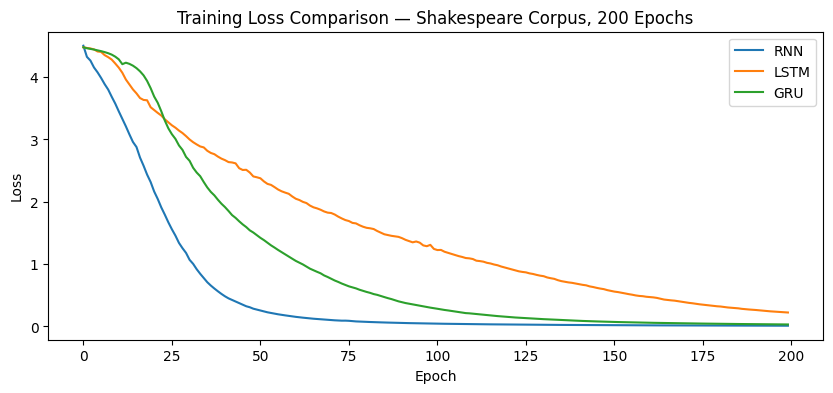

In [15]:
plt.figure(figsize=(10,4))
plt.plot(custom_rnn_history.history['loss'], label='RNN')
plt.plot(custom_lstm_history.history['loss'], label='LSTM')
plt.plot(custom_gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison — Shakespeare Corpus, 200 Epochs")
plt.legend()
plt.show()

## Task 5: Generate 10 words instead of 5

In [19]:
def generate_text_with_temp(model, seed_text, next_words=20, temperature=1.0):
    for _ in range(next_words):
        token_list = custom_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len-1, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]
        # Applying a higher temperature to force diversity
        preds = np.log(preds + 1e-7) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        predicted = np.random.choice(len(preds), p=preds)

        output_word = ""
        for word, index in custom_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Using a high temperature (1.5) to force the models to diverge
seed = "Artificial Intelligence (AI) has rapidly transformed from"
print("RNN (Temp 1.5) :", generate_text_with_temp(custom_rnn_model, seed, 20, 1.5))
print("LSTM (Temp 1.5):", generate_text_with_temp(custom_lstm_model, seed, 20, 1.5))
print("GRU (Temp 1.5) :", generate_text_with_temp(custom_gru_model, seed, 20, 1.5))

RNN (Temp 1.5) : Artificial Intelligence (AI) has rapidly transformed from a futuristic concept into an indispensable cornerstone of modern civilization time tasks core concept refers to the fraudulent of digital
LSTM (Temp 1.5): Artificial Intelligence (AI) has rapidly transformed from from core futuristic indispensable an concept into cornerstone civilization civilization civilization at its of the refers to time ability at
GRU (Temp 1.5) : Artificial Intelligence (AI) has rapidly transformed from a a futuristic concept into an indispensable cornerstone of modern civilization to the human core ai refers to the ability


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**